In [14]:
from IPython.display import Image
from Structure_information import DHN
import random


In [15]:
DHN_3=DHN("Directed",layout="spring")
DHN_3.Graph_From_Excel("C:\\Users\\sserranose\\OneDrive - INSA Lyon\\Bureau\\Code\\Panda_pipes\\Simulation_Bases\\Main_3\\Multi_plant_simulation_information.xlsx")
DHN_3.create_pandapipes_plus_initialization()
DHN_3.Creation_objects()

input_variables={"pipe_objects":{'T_amb':[273.3]},
                 "Consumer":[{"Q_building_profile":[150000],"T_return_design": 305},{"Q_building_profile":[150000],"T_return_design": 305},
                             {"Q_building_profile":[150000],"T_return_design": 305},{"Q_building_profile":[150000],"T_return_design": 305},
                             {"Q_building_profile":[150000],"T_return_design": 305},{"Q_building_profile":[150000],"T_return_design": 305},
                             {"Q_building_profile":[150000],"T_return_design": 305},{"Q_building_profile":[150000],"T_return_design": 305},
                             {"Q_building_profile":[150000],"T_return_design": 305}],
                "Slack_Central_production":{"T_out_design":377,"P_out_design":3,"P_lift_design":0.5},
                "HP_actors":[{"mode":[],"T_cons":[],"Q_consumer":[],'dT_water': []}],
                "Storage_actors":[{"mass_flow":[],'T_amb':[]}],
                "multi_plant":[{"T_out_design":376,"Q_nominal":[300000]},{"T_out_design":377,"Q_nominal":[250000]}]}


im here 


In [16]:
DHN_3.net.heat_consumer

,name,from_junction,to_junction,qext_w,controlled_mdot_kg_per_s,deltat_k,treturn_k,in_service,type
0,N3_Consumer,5,6,150000.0,NaN,NaN,305.0,True,heat_consumer
1,N4_Consumer,7,8,150000.0,NaN,NaN,305.0,True,heat_consumer
2,N5_Consumer,9,10,150000.0,NaN,NaN,305.0,True,heat_consumer
3,N8_Consumer,15,16,150000.0,NaN,NaN,305.0,True,heat_consumer
4,N9_Consumer,17,18,150000.0,NaN,NaN,305.0,True,heat_consumer
5,N10_Consumer,19,20,150000.0,NaN,NaN,305.0,True,heat_consumer
6,N15_Consumer,30,31,150000.0,NaN,NaN,305.0,True,heat_consumer
7,N16_Consumer,32,33,150000.0,NaN,NaN,305.0,True,heat_consumer
8,N17_Consumer,34,35,150000.0,NaN,NaN,305.0,True,heat_consumer


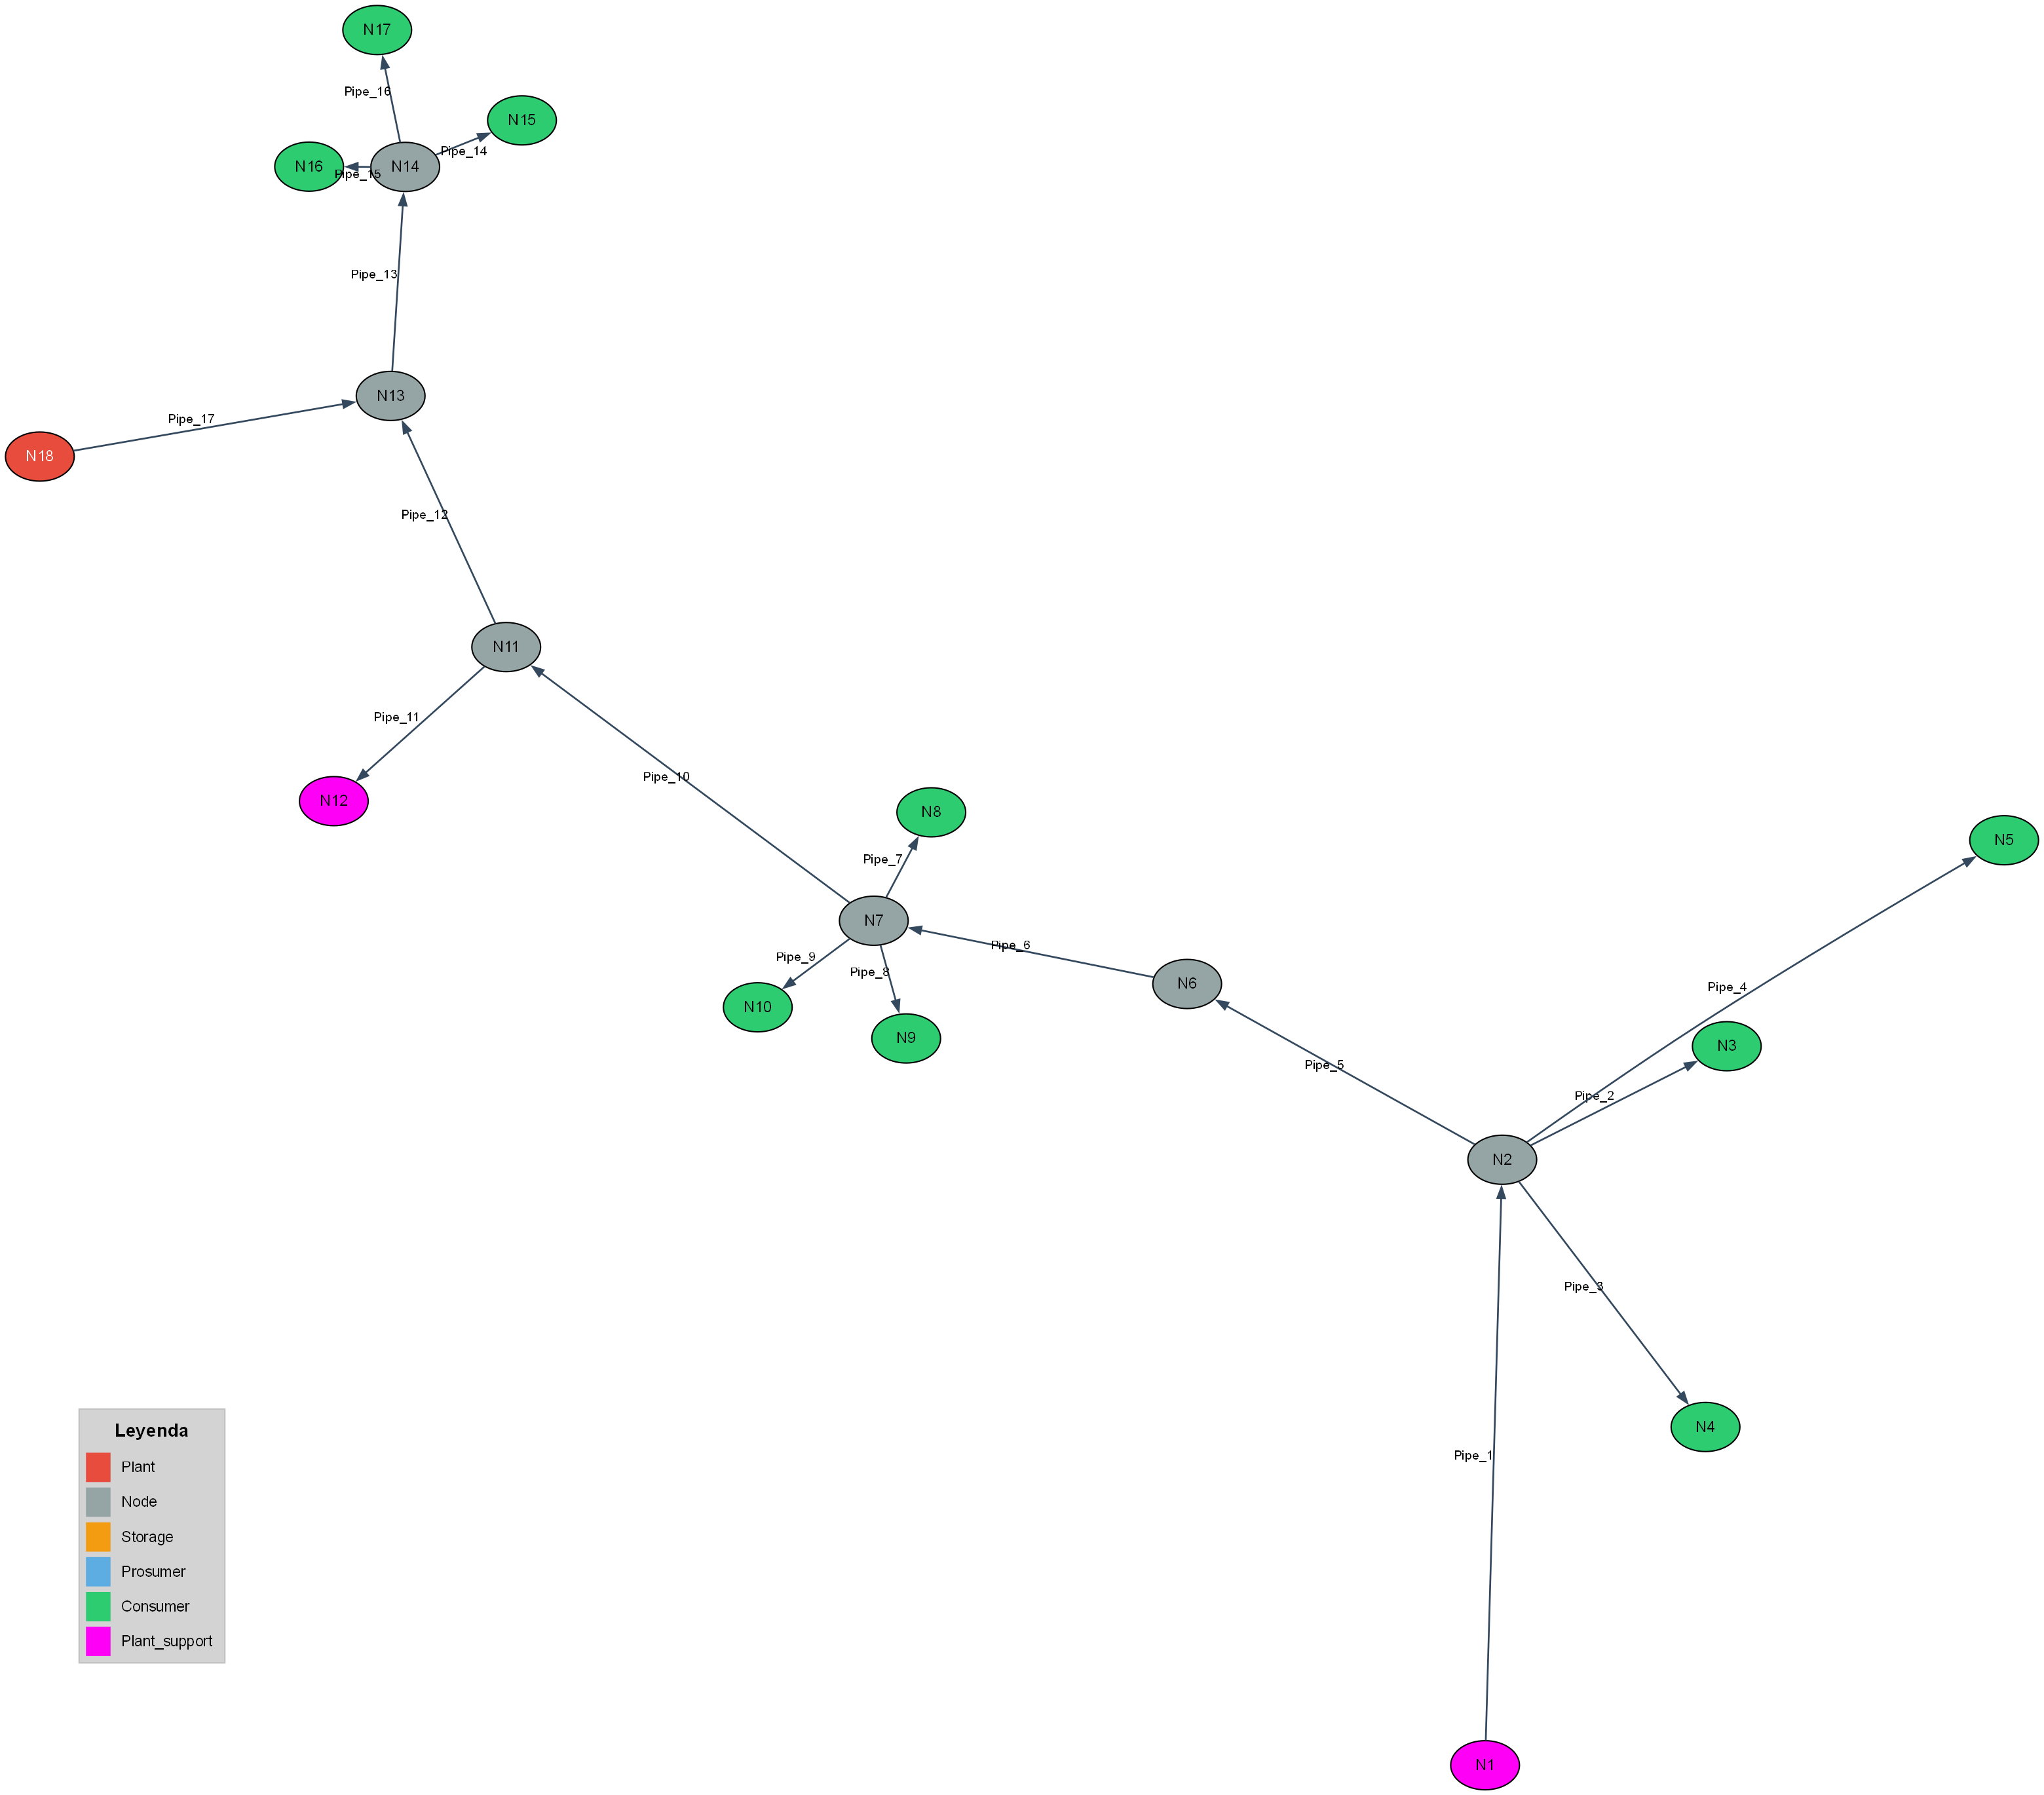

In [18]:
Image("network.png") 

In [19]:
DHN_3.def_input_variables_simulation(consumer_actors=DHN_3.Consumer_actors,slack_plant=DHN_3.slack_plant,
                                   input_variables=input_variables,HP_actors=DHN_3.HP_actors,Storage_actors=DHN_3.Storage_actors,
                                   multi_plant_actors=DHN_3.multi_plant_actors,pipe_objects=DHN_3.Pipe_objects)

T_prev={}
Dynamic_actors=DHN_3.multi_plant_actors["Object"]+DHN_3.HP_actors["Object"]+DHN_3.Storage_actors["Object"]
for a in Dynamic_actors:
    T_prev[a.name]=random.uniform(35+273.15,60+273.15)  
DHN_3.simulate_period_time(DHN_3.net,consumer_actors=DHN_3.Consumer_actors,slack_plant=DHN_3.slack_plant,
                                   HP_actors=DHN_3.HP_actors,Storage_actors=DHN_3.Storage_actors,
                                   multi_plant_actors=DHN_3.multi_plant_actors,
                                   pipe_objects=DHN_3.Pipe_objects,
                                   T_prev=T_prev,print_iteration=False,n_hours=1,
                                   tol_k=1E-6,max_iter=1000,relax=1)
DHN_3.generate_report(input_variables, Detailed_report=True,generate_data=True,write_detailed_report_name="simulation_report.txt",data_report_name="simulation_data_report.xlsx")


In [20]:
DHN_3.net.flow_control

,name,from_junction,to_junction,controlled_mdot_kg_per_s,control_active,in_service,type
0,Flow_control_support_plantN1,1,0,1.000903,True,True,fc
1,Flow_control_support_plantN12,24,23,0.822736,True,True,fc


In [21]:
DHN_3.net.circ_pump_mass

,name,return_junction,flow_junction,p_flow_bar,t_flow_k,mdot_flow_kg_per_s,in_service,type
0,Plant_support_circ_pump_N1,2,1,2.5,376.0,1.000903,True,pt
1,Plant_support_circ_pump_N12,25,24,2.5,377.0,0.822736,True,pt


In [22]:
DHN_3.net.flow_control


,name,from_junction,to_junction,controlled_mdot_kg_per_s,control_active,in_service,type
0,Flow_control_support_plantN1,1,0,1.000903,True,True,fc
1,Flow_control_support_plantN12,24,23,0.822736,True,True,fc
